In [1]:
# ============================================================
# DDPG FOR POWER ALLOCATION IN COGNITIVE RADIO
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
from collections import deque
import random

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: SYSTEM PARAMETERS
# ============================================================

Pp = 60e-3          # Primary user power (60 mW)
Pt = 100e-3         # Max secondary power (100 mW)
q  = 1e-3           # Interference threshold
sigma2_s = 0.001    # Noise at secondary receiver
sigma2_e = 0.001    # Noise at eavesdropper
alpha = 1.7         # Path loss exponent

d_s, d_e, d_p = 10.0, 20.0, 10.0
c_s, c_e = 20.0, 20.0

STATE_DIM = 8       # Input features
ACTION_DIM = 1      # Power Ps
ACTION_MAX = Pt     # Max power
ACTION_MIN = 0.0    # Min power

print("Parameters loaded.")

Parameters loaded.


In [2]:
# ============================================================
# STEP 2: WIRELESS ENVIRONMENT
# ============================================================

class WirelessEnv:
    """
    Cognitive radio environment for DDPG.
    
    State:  channel coefficients
    Action: transmit power Ps
    Reward: secrecy rate - penalties
    """
    
    def __init__(self, Pp, Pt, q, sigma2_s, sigma2_e, alpha):
        self.Pp = Pp
        self.Pt = Pt
        self.q = q
        self.sigma2_s = sigma2_s
        self.sigma2_e = sigma2_e
        self.alpha = alpha
        self.d_s, self.d_e, self.d_p = 10.0, 20.0, 10.0
        self.c_s, self.c_e = 20.0, 20.0
    
    def _generate_channels(self):
        """Generate one random channel realization."""
        rho = lambda: (np.random.randn() + 1j*np.random.randn()) / np.sqrt(2)
        
        h_s = rho() * np.sqrt(self.d_s**(-self.alpha))
        h_p = rho() * np.sqrt(self.d_p**(-self.alpha))
        h_e = rho() * np.sqrt(self.d_e**(-self.alpha))
        g_s = rho() * np.sqrt(self.c_s**(-self.alpha))
        g_e = rho() * np.sqrt(self.c_e**(-self.alpha))
        
        return h_s, h_p, h_e, g_s, g_e
    
    def reset(self):
        """Start a new episode with fresh channels."""
        self.h_s, self.h_p, self.h_e, self.g_s, self.g_e = self._generate_channels()
        
        # State: absolute values of channels
        state = np.array([
            np.abs(self.h_s), np.abs(self.h_p), np.abs(self.h_e),
            np.abs(self.g_s), np.abs(self.g_e),
            0.0, 0.0, 0.0   # epsilon values (perfect CSI = 0)
        ], dtype=np.float32)
        
        return state
    
    def step(self, action):
        """
        Apply action (power Ps), get reward.
        """
        # Clip action to valid range
        Ps = np.clip(action[0], self.ACTION_MIN, self.ACTION_MAX) if hasattr(self, 'ACTION_MIN') else np.clip(action[0], 0, self.Pt)
        
        # Compute SINRs
        sinr_s = (Ps * np.abs(self.h_s)**2) / (self.Pp * np.abs(self.g_s)**2 + self.sigma2_s)
        sinr_e = (Ps * np.abs(self.h_e)**2) / (self.Pp * np.abs(self.g_e)**2 + self.sigma2_e)
        
        # Secrecy rate
        secrecy = np.log2(1 + sinr_s) - np.log2(1 + sinr_e)
        
        # Constraints
        interference = Ps * np.abs(self.h_p)**2
        penalty_interference = 100 * max(0, interference - self.q)
        penalty_power = 100 * max(0, Ps - self.Pt)
        
        # Reward
        reward = secrecy - penalty_interference - penalty_power
        
        # Next state (same channels — static scenario)
        next_state = np.array([
            np.abs(self.h_s), np.abs(self.h_p), np.abs(self.h_e),
            np.abs(self.g_s), np.abs(self.g_e),
            0.0, 0.0, 0.0
        ], dtype=np.float32)
        
        done = True  # One-shot decision
        
        return next_state, reward, done, {'secrecy': secrecy, 'Ps': Ps}
    
    def sample_action(self):
        """Random action for initialization."""
        return np.array([np.random.uniform(0, self.Pt)], dtype=np.float32)


env = WirelessEnv(Pp, Pt, q, sigma2_s, sigma2_e, alpha)
print("Environment ready.")

Environment ready.


In [3]:
# ============================================================
# STEP 3: ACTOR NETWORK (Policy)
# ============================================================

class Actor(tf.keras.Model):
    """
    Actor: maps state → action (deterministic policy)
    μ(s|θμ)
    """
    def __init__(self, state_dim, action_dim, action_max, hidden=256):
        super().__init__()
        self.action_max = action_max
        
        self.fc1 = layers.Dense(hidden, activation='relu')
        self.fc2 = layers.Dense(hidden, activation='relu')
        self.fc3 = layers.Dense(hidden // 2, activation='relu')
        self.out = layers.Dense(action_dim, activation='sigmoid')  # [0,1] then scale
        
    def call(self, state):
        x = self.fc1(state)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.out(x)
        return x * self.action_max  # scale to [0, Pt]


# Test
actor = Actor(STATE_DIM, ACTION_DIM, ACTION_MAX)
test_state = tf.constant(np.random.randn(1, 8), dtype=tf.float32)
test_action = actor(test_state)
print("Actor output shape:", test_action.shape)
print("Actor output:", test_action.numpy())

Actor output shape: (1, 1)
Actor output: [[0.04323886]]


In [4]:
# ============================================================
# STEP 4: CRITIC NETWORK (Q-value)
# ============================================================

class Critic(tf.keras.Model):
    """
    Critic: maps (state, action) → Q-value
    Q(s,a|θQ)
    """
    def __init__(self, state_dim, action_dim, hidden=256):
        super().__init__()
        
        # State pathway
        self.fc1 = layers.Dense(hidden, activation='relu')
        self.fc2 = layers.Dense(hidden, activation='relu')
        self.fc3 = layers.Dense(hidden // 2, activation='relu')
        
        # Action pathway (merged later)
        self.action_fc = layers.Dense(hidden // 2, activation='relu')
        
        # Output
        self.out = layers.Dense(1)
        
    def call(self, state, action):
        x = self.fc1(state)
        x = self.fc2(x)
        x = self.fc3(x)
        
        a = self.action_fc(action)
        
        # Concatenate state and action features
        merged = layers.Concatenate()([x, a])
        return self.out(merged)


# Test
critic = Critic(STATE_DIM, ACTION_DIM)
test_q = critic(test_state, test_action)
print("Critic output shape:", test_q.shape)
print("Critic output:", test_q.numpy())

Critic output shape: (1, 1)
Critic output: [[0.03980821]]


In [6]:
# ============================================================
# STEP 5: REPLAY BUFFER
# ============================================================

class ReplayBuffer:
    """
    Stores (state, action, reward, next_state, done) tuples.
    Samples random mini-batches for training.
    """
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.float32),
            np.array(rewards, dtype=np.float32).reshape(-1, 1),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32).reshape(-1, 1)
        )
    
    def __len__(self):
        return len(self.buffer)


buffer = ReplayBuffer(capacity=100000)
print("Replay buffer ready.")

Replay buffer ready.


In [7]:
# ============================================================
# STEP 6: EXPLORATION NOISE
# ============================================================

class OUNoise:
    """
    Ornstein-Uhlenbeck process for temporally correlated exploration.
    """
    def __init__(self, action_dim, mu=0.0, theta=0.15, sigma=0.1, dt=1e-2):
        self.action_dim = action_dim
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.dt = dt
        self.reset()
    
    def reset(self):
        self.state = np.ones(self.action_dim) * self.mu
    
    def noise(self):
        x = self.state
        dx = self.theta * (self.mu - x) * self.dt + \
             self.sigma * np.sqrt(self.dt) * np.random.randn(self.action_dim)
        self.state = x + dx
        return self.state


noise = OUNoise(ACTION_DIM)
print("OU Noise ready. Sample:", noise.noise())

OU Noise ready. Sample: [-0.00469474]


In [8]:
# ============================================================
# STEP 7: DDPG AGENT
# ============================================================

class DDPGAgent:
    """
    Deep Deterministic Policy Gradient Agent.
    """
    def __init__(self, state_dim, action_dim, action_max,
                 actor_lr=1e-4, critic_lr=1e-3,
                 gamma=0.99, tau=0.005, buffer_capacity=100000,
                 batch_size=64):
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.action_max = action_max
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        
        # ---- Actor networks ----
        self.actor = Actor(state_dim, action_dim, action_max)
        self.actor_target = Actor(state_dim, action_dim, action_max)
        self.actor_target.set_weights(self.actor.get_weights())
        self.actor_optimizer = optimizers.Adam(actor_lr)
        
        # ---- Critic networks ----
        self.critic = Critic(state_dim, action_dim)
        self.critic_target = Critic(state_dim, action_dim)
        self.critic_target.set_weights(self.critic.get_weights())
        self.critic_optimizer = optimizers.Adam(critic_lr)
        
        # ---- Replay buffer ----
        self.buffer = ReplayBuffer(buffer_capacity)
        
        # ---- Exploration noise ----
        self.noise = OUNoise(action_dim)
    
    def select_action(self, state, add_noise=True):
        """Choose action using actor + exploration noise."""
        state_tf = tf.constant(state.reshape(1, -1), dtype=tf.float32)
        action = self.actor(state_tf).numpy().flatten()
        
        if add_noise:
            action += self.noise.noise() * self.action_max * 0.1
        
        # Clip to valid range
        action = np.clip(action, 0, self.action_max)
        return action
    
    def store_transition(self, state, action, reward, next_state, done):
        self.buffer.add(state, action, reward, next_state, done)
    
    def train_step(self):
        """One gradient update for actor and critic."""
        if len(self.buffer) < self.batch_size:
            return None, None
        
        # Sample mini-batch
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        states = tf.constant(states, dtype=tf.float32)
        actions = tf.constant(actions, dtype=tf.float32)
        rewards = tf.constant(rewards, dtype=tf.float32)
        next_states = tf.constant(next_states, dtype=tf.float32)
        dones = tf.constant(dones, dtype=tf.float32)
        
        # ---- Critic update ----
        with tf.GradientTape() as tape:
            # Target action from target actor
            target_actions = self.actor_target(next_states)
            
            # Target Q-value
            target_q = self.critic_target(next_states, target_actions)
            y = rewards + self.gamma * (1 - dones) * target_q
            
            # Current Q-value
            current_q = self.critic(states, actions)
            
            # Critic loss
            critic_loss = tf.reduce_mean(tf.square(y - current_q))
        
        critic_grads = tape.gradient(critic_loss, self.critic.trainable_variables)
        self.critic_optimizer.apply_gradients(
            zip(critic_grads, self.critic.trainable_variables)
        )
        
        # ---- Actor update ----
        with tf.GradientTape() as tape:
            # Actor's action
            new_actions = self.actor(states)
            
            # Actor wants to maximize Q
            actor_loss = -tf.reduce_mean(self.critic(states, new_actions))
        
        actor_grads = tape.gradient(actor_loss, self.actor.trainable_variables)
        self.actor_optimizer.apply_gradients(
            zip(actor_grads, self.actor.trainable_variables)
        )
        
        # ---- Soft update target networks ----
        self._soft_update(self.actor, self.actor_target)
        self._soft_update(self.critic, self.critic_target)
        
        return actor_loss.numpy(), critic_loss.numpy()
    
    def _soft_update(self, source, target):
        """θ_target ← τ·θ_source + (1-τ)·θ_target"""
        for s_var, t_var in zip(source.trainable_variables, target.trainable_variables):
            t_var.assign(self.tau * s_var + (1 - self.tau) * t_var)


agent = DDPGAgent(STATE_DIM, ACTION_DIM, ACTION_MAX)
print("DDPG Agent ready.")

DDPG Agent ready.


In [9]:
# ============================================================
# STEP 8: TRAINING LOOP
# ============================================================

def train_ddpg(env, agent, n_episodes=5000, verbose_every=500):
    """
    Main training loop for DDPG.
    """
    rewards_history = []
    secrecy_history = []
    actor_losses = []
    critic_losses = []
    
    for episode in range(n_episodes):
        # Reset environment
        state = env.reset()
        agent.noise.reset()
        
        # Select action with exploration
        action = agent.select_action(state, add_noise=True)
        
        # Take action
        next_state, reward, done, info = env.step(action)
        
        # Store transition
        agent.store_transition(state, action, reward, next_state, done)
        
        # Train
        actor_loss, critic_loss = agent.train_step()
        
        # Record
        rewards_history.append(reward)
        secrecy_history.append(info['secrecy'])
        if actor_loss is not None:
            actor_losses.append(actor_loss)
            critic_losses.append(critic_loss)
        
        # Print progress
        if (episode + 1) % verbose_every == 0:
            avg_reward = np.mean(rewards_history[-verbose_every:])
            avg_secrecy = np.mean(secrecy_history[-verbose_every:])
            print(f"Episode {episode+1:5d} | "
                  f"Avg Reward: {avg_reward:8.4f} | "
                  f"Avg Secrecy: {avg_secrecy:8.4f} | "
                  f"Actor Loss: {actor_loss if actor_loss else 0:.4f} | "
                  f"Critic Loss: {critic_loss if critic_loss else 0:.4f}")
    
    return rewards_history, secrecy_history, actor_losses, critic_losses


# Train
print("Starting DDPG training...")
rewards, secrecy, actor_loss, critic_loss = train_ddpg(
    env, agent, n_episodes=5000, verbose_every=500
)

Starting DDPG training...
Episode   500 | Avg Reward:   0.4898 | Avg Secrecy:   0.5786 | Actor Loss: -0.4713 | Critic Loss: 0.0127
Episode  1000 | Avg Reward:   0.4837 | Avg Secrecy:   0.6079 | Actor Loss: -0.4247 | Critic Loss: 0.0134
Episode  1500 | Avg Reward:   0.5469 | Avg Secrecy:   0.6676 | Actor Loss: -0.3696 | Critic Loss: 0.0060
Episode  2000 | Avg Reward:   0.4556 | Avg Secrecy:   0.5855 | Actor Loss: -0.5812 | Critic Loss: 0.0063
Episode  2500 | Avg Reward:   0.5223 | Avg Secrecy:   0.6322 | Actor Loss: -0.6160 | Critic Loss: 0.0032
Episode  3000 | Avg Reward:   0.4830 | Avg Secrecy:   0.6153 | Actor Loss: -0.5503 | Critic Loss: 0.0009
Episode  3500 | Avg Reward:   0.4768 | Avg Secrecy:   0.5925 | Actor Loss: -0.4980 | Critic Loss: 0.0027
Episode  4000 | Avg Reward:   0.5129 | Avg Secrecy:   0.6297 | Actor Loss: -0.4595 | Critic Loss: 0.0013
Episode  4500 | Avg Reward:   0.5154 | Avg Secrecy:   0.6370 | Actor Loss: -0.6778 | Critic Loss: 0.0023
Episode  5000 | Avg Reward:  

In [11]:
# ============================================================
# STEP 9: EVALUATION
# ============================================================

def evaluate_agent(env, agent, n_episodes=1000):
    """
    Evaluate trained DDPG agent (no exploration noise).
    """
    rewards = []
    secrecy_rates = []
    powers = []
    
    for _ in range(n_episodes):
        state = env.reset()
        action = agent.select_action(state, add_noise=False)
        _, reward, _, info = env.step(action)
        
        rewards.append(reward)
        secrecy_rates.append(info['secrecy'])
        powers.append(info['Ps'])
    
    return np.array(rewards), np.array(secrecy_rates), np.array(powers)


# Evaluate
rewards_eval, secrecy_eval, powers_eval = evaluate_agent(env, agent, n_episodes=1000)

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"Mean Secrecy Rate:  {np.mean(secrecy_eval):.4f} bps/Hz")
print(f"Std Secrecy Rate:   {np.std(secrecy_eval):.4f}")
print(f"Mean Power:         {np.mean(powers_eval)*1000:.2f} mW")
print(f"Min Power:          {np.min(powers_eval)*1000:.2f} mW")
print(f"Max Power:          {np.max(powers_eval)*1000:.2f} mW")
print(f"Mean Reward:        {np.mean(rewards_eval):.4f}")


EVALUATION RESULTS
Mean Secrecy Rate:  0.6580 bps/Hz
Std Secrecy Rate:   0.8746
Mean Power:         100.00 mW
Min Power:          100.00 mW
Max Power:          100.00 mW
Mean Reward:        0.5413


In [12]:
# ============================================================
# STEP 10: COMPARISON WITH TRADITIONAL OPTIMIZATION
# ============================================================

from scipy.optimize import minimize
import time

def optimal_power_traditional(h_s, h_p, h_e, g_s, g_e, Pp, Pt, q, s2s, s2e):
    """Traditional optimization for comparison."""
    a = np.abs(h_s)**2 / (Pp * np.abs(g_s)**2 + s2s)
    b = np.abs(h_e)**2 / (Pp * np.abs(g_e)**2 + s2e)
    ub = min(q / np.abs(h_p)**2, Pt)
    if ub <= 0:
        return 0.0
    res = minimize(lambda x: -(np.log2(1 + a*x) - np.log2(1 + b*x)),
                   ub/2, bounds=[(0, ub)], method='L-BFGS-B')
    return res.x[0]


# Test on same channels
N_COMPARE = 500

ddpg_secrecy = []
opt_secrecy = []
ddpg_time = []
opt_time = []

for _ in range(N_COMPARE):
    state = env.reset()
    
    # DDPG
    t0 = time.time()
    action = agent.select_action(state, add_noise=False)
    _, _, _, info = env.step(action)
    ddpg_time.append(time.time() - t0)
    ddpg_secrecy.append(info['secrecy'])
    
    # Traditional
    t0 = time.time()
    Ps_opt = optimal_power_traditional(
        env.h_s, env.h_p, env.h_e, env.g_s, env.g_e,
        Pp, Pt, q, sigma2_s, sigma2_e
    )
    opt_time.append(time.time() - t0)
    
    sinr_s = (Ps_opt * np.abs(env.h_s)**2) / (Pp * np.abs(env.g_s)**2 + sigma2_s)
    sinr_e = (Ps_opt * np.abs(env.h_e)**2) / (Pp * np.abs(env.g_e)**2 + sigma2_e)
    opt_secrecy.append(np.log2(1 + sinr_s) - np.log2(1 + sinr_e))


print("\n" + "="*50)
print("DDPG vs TRADITIONAL OPTIMIZATION")
print("="*50)
print(f"DDPG  Mean Secrecy: {np.mean(ddpg_secrecy):.4f} bps/Hz")
print(f"Optim Mean Secrecy: {np.mean(opt_secrecy):.4f} bps/Hz")
print(f"Secrecy Gap:        {np.mean(opt_secrecy) - np.mean(ddpg_secrecy):.4f}")
print(f"Optimality:         {np.mean(ddpg_secrecy)/np.mean(opt_secrecy)*100:.2f}%")
print(f"\nDDPG  Avg Time: {np.mean(ddpg_time)*1e6:.2f} µs")
print(f"Optim Avg Time: {np.mean(opt_time)*1e3:.2f} ms")
print(f"Speedup:        {np.mean(opt_time)/np.mean(ddpg_time):.0f}x")


DDPG vs TRADITIONAL OPTIMIZATION
DDPG  Mean Secrecy: 0.6210 bps/Hz
Optim Mean Secrecy: 0.5429 bps/Hz
Secrecy Gap:        -0.0781
Optimality:         114.39%

DDPG  Avg Time: 9999.00 µs
Optim Avg Time: 1.71 ms
Speedup:        0x


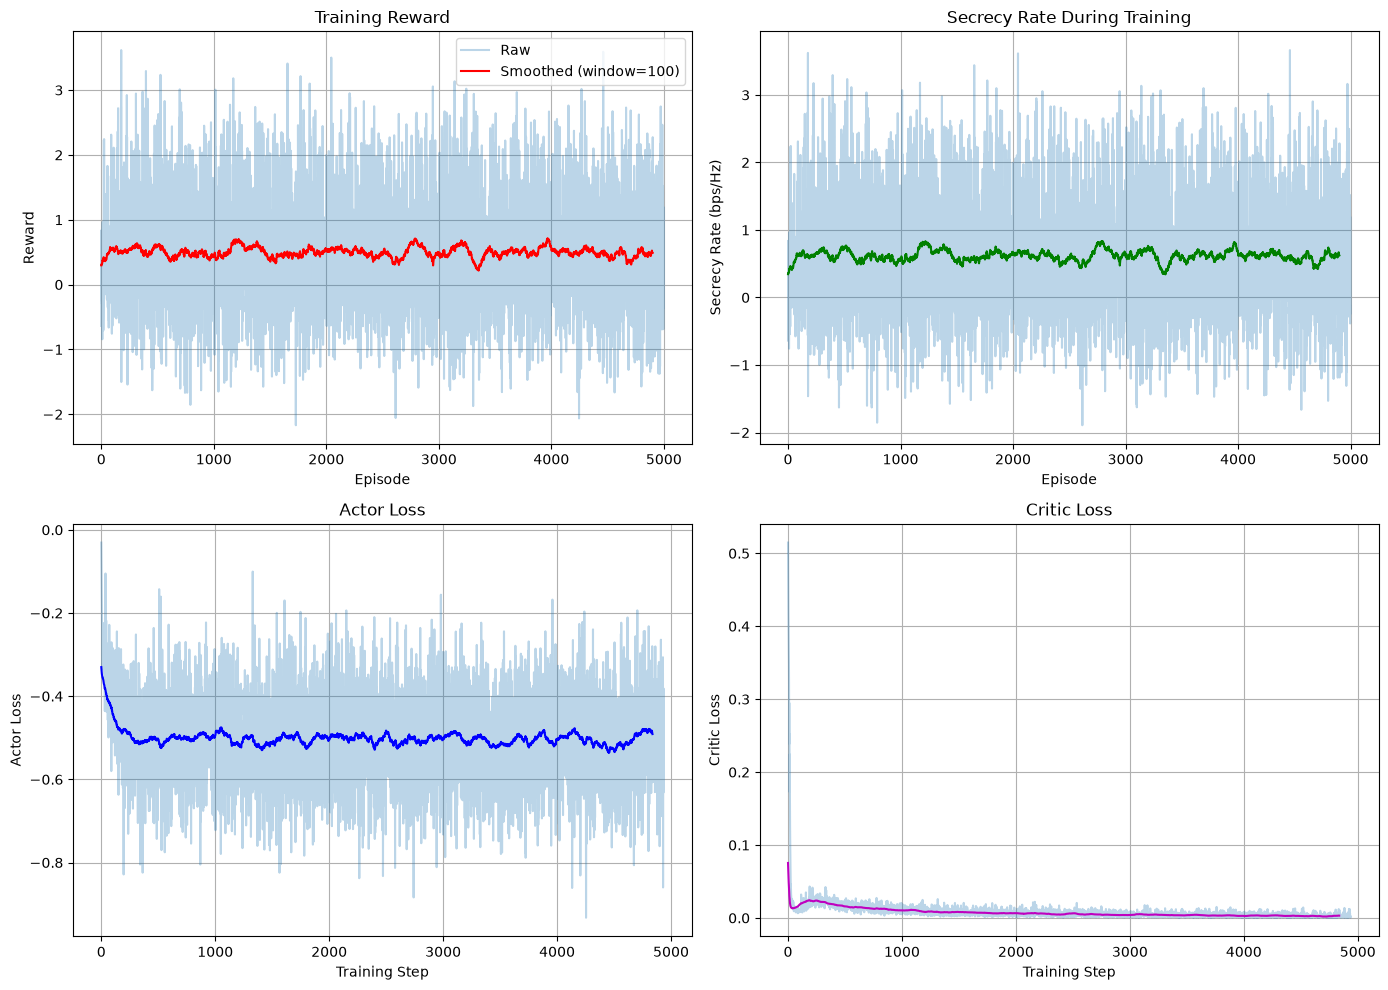

In [13]:
# ============================================================
# STEP 11: VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reward over episodes
axes[0, 0].plot(rewards, alpha=0.3, label='Raw')
window = 100
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
axes[0, 0].plot(smoothed, 'r-', label=f'Smoothed (window={window})')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].set_title('Training Reward')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Secrecy over episodes
axes[0, 1].plot(secrecy, alpha=0.3)
smoothed_s = np.convolve(secrecy, np.ones(window)/window, mode='valid')
axes[0, 1].plot(smoothed_s, 'g-')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Secrecy Rate (bps/Hz)')
axes[0, 1].set_title('Secrecy Rate During Training')
axes[0, 1].grid(True)

# Actor loss
axes[1, 0].plot(actor_loss, alpha=0.3)
if len(actor_loss) > window:
    smoothed_a = np.convolve(actor_loss, np.ones(window)/window, mode='valid')
    axes[1, 0].plot(smoothed_a, 'b-')
axes[1, 0].set_xlabel('Training Step')
axes[1, 0].set_ylabel('Actor Loss')
axes[1, 0].set_title('Actor Loss')
axes[1, 0].grid(True)

# Critic loss
axes[1, 1].plot(critic_loss, alpha=0.3)
if len(critic_loss) > window:
    smoothed_c = np.convolve(critic_loss, np.ones(window)/window, mode='valid')
    axes[1, 1].plot(smoothed_c, 'm-')
axes[1, 1].set_xlabel('Training Step')
axes[1, 1].set_ylabel('Critic Loss')
axes[1, 1].set_title('Critic Loss')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('ddpg_training.png', dpi=150)
plt.show()